In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,27-12-2012,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,24-07-2011,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,23-09-2014,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,10/10/2013,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,30-10-2014,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,5/8/2014,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,"Jul 11, 2011",Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,28-12-2011,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,11/8/2013,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51370 non-null  int64  
 1   Order ID        51370 non-null  str    
 2   Order Date      51370 non-null  str    
 3   Ship Date       51370 non-null  str    
 4   Ship Mode       51370 non-null  str    
 5   Customer ID     51370 non-null  str    
 6   Customer Name   51336 non-null  str    
 7   Segment         51370 non-null  str    
 8   City            51351 non-null  str    
 9   State           51339 non-null  str    
 10  Country         51370 non-null  str    
 11  Postal Code     51370 non-null  int64  
 12  Market          51370 non-null  str    
 13  Region          51370 non-null  str    
 14  Product ID      51370 non-null  str    
 15  Category        51370 non-null  str    
 16  Sub-Category    51370 non-null  str    
 17  Product Name    51370 non-null  str    
 1

In [4]:
# Which global Markets or Regions are generating the highest revenue, and do they have the healthiest profit margins?

In [9]:
profit_margin = (df['Sales'].sum() / df['Profit'].sum()).round(2)
print(profit_margin,'%')

8.61 %


In [32]:
market_region_sales_and_profit = df.groupby(
    [
        'Market',
        'Region'
    ]
)[
    [
        'Sales','Profit'
    ]
].agg(
    market_total_sales = ('Sales','sum'),
    market_total_profit = ('Profit','sum'),
).round(2)
market_region_sales_and_profit

market_total_sales  market_total_profit
Market Region                                                 
APAC   Central Asia             756830.78            134179.11
       North Asia               848357.30            165601.64
       Oceania                 1102795.80            120028.51
       Southeast Asia           886398.14             18410.09
Africa Africa                   784776.68             89017.23
Canada Canada                    66928.17             17817.39
EMEA   EMEA                     806467.88             43764.47
EU     Central                 1722774.07            215845.90
       North                    626257.48             91977.69
       South                    593802.03             65707.38
LATAM  Caribbean                324991.55             34613.26
       Central                  600707.02             56204.85
       North                    624257.65            103073.28
       South                    618624.23             27963.08
US     Central                  503680.73             39691.17
       East                     678967.47             91559.76
       South                    391721.90             46749.48
       West                     726917.86            108391.26

In [34]:
market_region_sales_and_profit2 = market_region_sales_and_profit

In [35]:
market_region_sales_and_profit2.reset_index(inplace=True)
market_region_sales_and_profit2

,Market,Region,market_total_sales,market_total_profit
0,APAC,Central Asia,756830.78,134179.11
1,APAC,North Asia,848357.30,165601.64
2,APAC,Oceania,1102795.80,120028.51
3,APAC,Southeast Asia,886398.14,18410.09
4,Africa,Africa,784776.68,89017.23
5,Canada,Canada,66928.17,17817.39
6,EMEA,EMEA,806467.88,43764.47
7,EU,Central,1722774.07,215845.90
8,EU,North,626257.48,91977.69
9,EU,South,593802.03,65707.38


In [37]:
sales_and_profit_by_market = market_region_sales_and_profit2.groupby('Market')[['market_total_sales','market_total_profit']].agg(
    total_sales_by_Market = ('market_total_sales','sum'),
    total_profit_by_Market = ('market_total_profit','sum'),
).round(2)
sales_and_profit_by_market

,total_sales_by_Market,total_profit_by_Market
Market,,
APAC,3594382.02,438219.35
Africa,784776.68,89017.23
Canada,66928.17,17817.39
EMEA,806467.88,43764.47
EU,2942833.58,373530.97
LATAM,2168580.45,221854.47
US,2301287.96,286391.67


In [42]:
profit_margin_by_market = (sales_and_profit_by_market['total_sales_by_Market'] / sales_and_profit_by_market['total_profit_by_Market']).round(2)
profit_margin_by_market

Market
APAC       8.20
Africa     8.82
Canada     3.76
EMEA      18.43
EU         7.88
LATAM      9.77
US         8.04
dtype: float64

In [45]:
sales_and_profit_by_market['profit_margin'] = profit_margin_by_market
sales_and_profit_by_market

,total_sales_by_Market,total_profit_by_Market,profit_margin
Market,,,
APAC,3594382.02,438219.35,8.2
Africa,784776.68,89017.23,8.82
Canada,66928.17,17817.39,3.76
EMEA,806467.88,43764.47,18.43
EU,2942833.58,373530.97,7.88
LATAM,2168580.45,221854.47,9.77
US,2301287.96,286391.67,8.04


In [51]:
market_region_sales_and_profit2.set_index('Market',inplace=True)
market_region_sales_and_profit2

,Region,market_total_sales,market_total_profit
Market,,,
APAC,Central Asia,756830.78,134179.11
APAC,North Asia,848357.30,165601.64
APAC,Oceania,1102795.80,120028.51
APAC,Southeast Asia,886398.14,18410.09
Africa,Africa,784776.68,89017.23
Canada,Canada,66928.17,17817.39
EMEA,EMEA,806467.88,43764.47
EU,Central,1722774.07,215845.90
EU,North,626257.48,91977.69


In [52]:
market_region_sales_and_profit2['total_sales_by_market'] = sales_and_profit_by_market['total_sales_by_Market']

In [53]:
market_region_sales_and_profit2

,Region,market_total_sales,market_total_profit,total_sales_by_market
Market,,,,
APAC,Central Asia,756830.78,134179.11,3594382.02
APAC,North Asia,848357.30,165601.64,3594382.02
APAC,Oceania,1102795.80,120028.51,3594382.02
APAC,Southeast Asia,886398.14,18410.09,3594382.02
Africa,Africa,784776.68,89017.23,784776.68
Canada,Canada,66928.17,17817.39,66928.17
EMEA,EMEA,806467.88,43764.47,806467.88
EU,Central,1722774.07,215845.90,2942833.58
EU,North,626257.48,91977.69,2942833.58


In [54]:
market_region_sales_and_profit2['total_profit_by_market'] = sales_and_profit_by_market['total_profit_by_Market']
market_region_sales_and_profit2['profit_margin'] = sales_and_profit_by_market['profit_margin']
market_region_sales_and_profit2

,Region,market_total_sales,market_total_profit,total_sales_by_market,total_profit_by_market,profit_margin
Market,,,,,,
APAC,Central Asia,756830.78,134179.11,3594382.02,438219.35,8.2
APAC,North Asia,848357.30,165601.64,3594382.02,438219.35,8.2
APAC,Oceania,1102795.80,120028.51,3594382.02,438219.35,8.2
APAC,Southeast Asia,886398.14,18410.09,3594382.02,438219.35,8.2
Africa,Africa,784776.68,89017.23,784776.68,89017.23,8.82
Canada,Canada,66928.17,17817.39,66928.17,17817.39,3.76
EMEA,EMEA,806467.88,43764.47,806467.88,43764.47,18.43
EU,Central,1722774.07,215845.90,2942833.58,373530.97,7.88
EU,North,626257.48,91977.69,2942833.58,373530.97,7.88


In [55]:
market_region_sales_and_profit2.reset_index(inplace=True)

In [56]:
market_region_sales_and_profit2

,Market,Region,market_total_sales,market_total_profit,total_sales_by_market,total_profit_by_market,profit_margin
0,APAC,Central Asia,756830.78,134179.11,3594382.02,438219.35,8.2
1,APAC,North Asia,848357.30,165601.64,3594382.02,438219.35,8.2
2,APAC,Oceania,1102795.80,120028.51,3594382.02,438219.35,8.2
3,APAC,Southeast Asia,886398.14,18410.09,3594382.02,438219.35,8.2
4,Africa,Africa,784776.68,89017.23,784776.68,89017.23,8.82
5,Canada,Canada,66928.17,17817.39,66928.17,17817.39,3.76
6,EMEA,EMEA,806467.88,43764.47,806467.88,43764.47,18.43
7,EU,Central,1722774.07,215845.90,2942833.58,373530.97,7.88
8,EU,North,626257.48,91977.69,2942833.58,373530.97,7.88
9,EU,South,593802.03,65707.38,2942833.58,373530.97,7.88


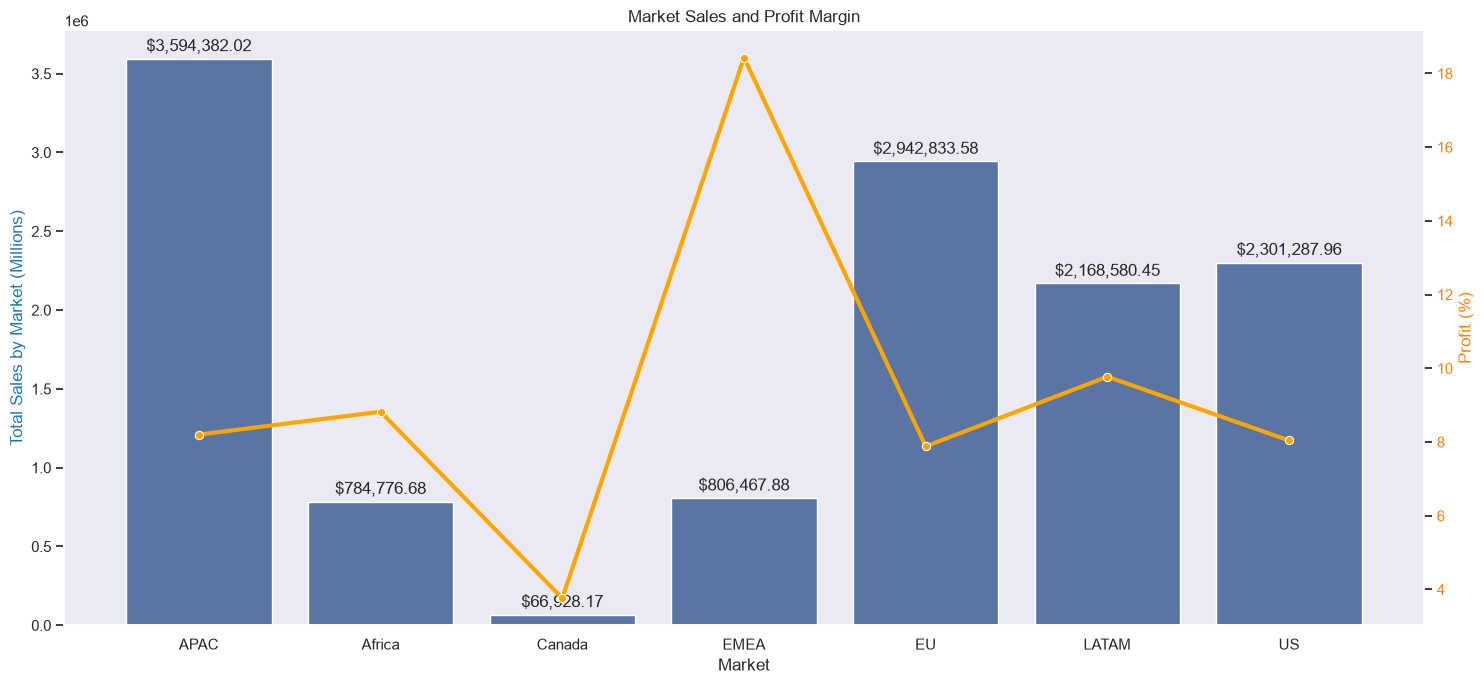

In [129]:
sns.set_theme()
fig, ax1 = plt.subplots(figsize=(15,7))

sns.barplot(
    data=market_region_sales_and_profit2,
    x='Market',
    y='total_sales_by_market',
    ax=ax1
)
ax1.set_ylabel('Total Sales by Market (Millions)',color='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(False)
ax1.bar_label(ax1.containers[0], fmt='${:,.2f}' , padding=3)

ax2 = ax1.twinx()
sns.lineplot(
    data=market_region_sales_and_profit2,
    x='Market',
    y='profit_margin',
    ax=ax2,
    marker='o',
    color='orange',
    lw=3
)
ax2.set_ylabel('Profit (%)',color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax2.grid(False)

plt.title('Market Sales and Profit Margin')
fig.tight_layout()

In [132]:
# Business Question 2:
# Which global Markets or Regions are generating the highest revenue, and do they have the healthiest profit margins?

# Answer:
# APAC is the highest recorded sales of $3,5m million while EMEA shows lesser sales of around $800k+, it displays 8% profit margin,
# EMEA performs better when it comes to profit margin of 18%.
# EU seconded the highest sales of $2,9m and a profit margin of 8%, almost same with APAC,
# while LATAM shows off a better performance in profit margin of almost 10%.